# Required packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [3]:
from itertools import product
from tqdm.notebook import tqdm, trange

In [4]:
from typing import Union

In [5]:
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox

In [6]:
from typing import Union

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats
import seaborn as sns

!conda install tqdm -y

# 6.1) Forecasting bandwidth usage for data centers

In [8]:
df_bandwidth = pd.read_csv('data/bandwidth.csv')

In [9]:
df_bandwidth.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hourly_bandwidth  10000 non-null  float64
dtypes: float64(1)
memory usage: 78.3 KB


In [10]:
timeindex = pd.date_range(start="2019-01", freq='h', periods=10000)
df_bandwidth.set_index(timeindex, inplace=True)
df_bandwidth.head()

,hourly_bandwidth
2019-01-01 00:00:00,1000.496714
2019-01-01 01:00:00,1000.969408
2019-01-01 02:00:00,1002.046019
2019-01-01 03:00:00,1004.702118
2019-01-01 04:00:00,1007.447816


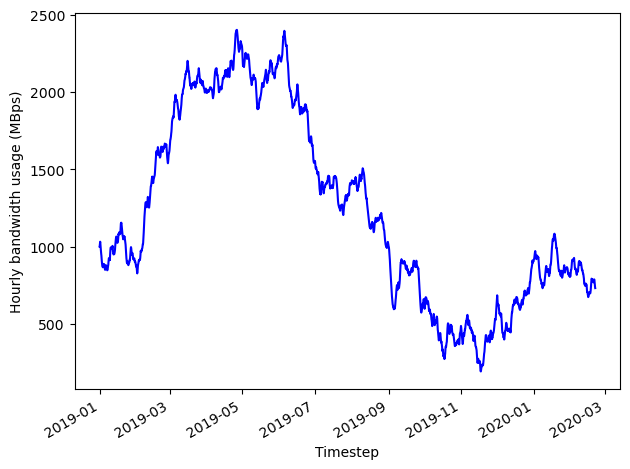

In [11]:
fig, ax = plt.subplots()
ax.plot(df_bandwidth, 'b-')
ax.set_xlabel('Timestep')
ax.set_ylabel('Hourly bandwidth usage (MBps)')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [12]:
adfuller(df_bandwidth.iloc[:, 0])

(np.float64(-0.8714653199452549),
 np.float64(0.7972240255014611),
 6,
 9993,
 {'1%': np.float64(-3.431004556246501),
  '5%': np.float64(-2.8618292749021865),
  '10%': np.float64(-2.5669239758928017)},
 np.float64(28347.577478302363))

In [13]:
adfuller(np.diff(df_bandwidth.iloc[:, 0]))

(np.float64(-20.69485386378904),
 0.0,
 5,
 9993,
 {'1%': np.float64(-3.431004556246501),
  '5%': np.float64(-2.8618292749021865),
  '10%': np.float64(-2.5669239758928017)},
 np.float64(28344.57207305265))

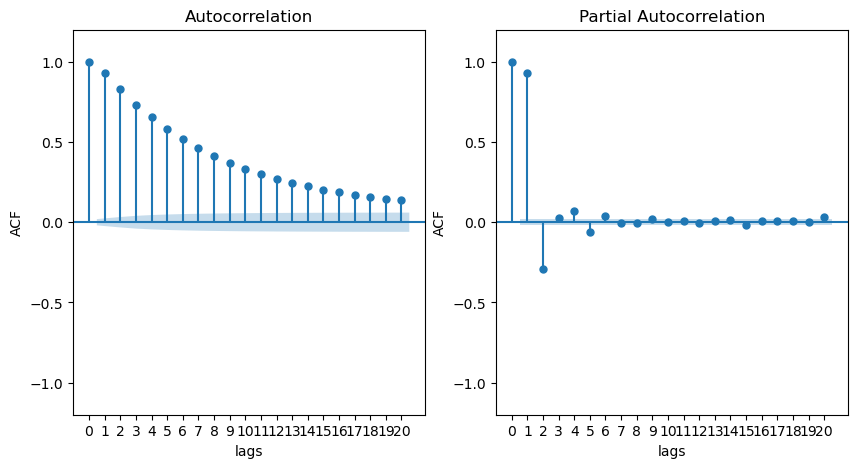

In [14]:
bandwidth_diff = np.diff(df_bandwidth.iloc[:, 0])
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
plot_acf(bandwidth_diff, lags=20, ax=ax[0])
ax[0].set_xlabel('lags')
ax[0].set_ylabel('ACF')
ax[0].set_xticks(np.arange(0, 21, 1))
ax[0].set_ylim([-1.2, 1.2])

plot_pacf(bandwidth_diff, lags=20, ax=ax[1])
ax[1].set_xlabel('lags')
ax[1].set_ylabel('ACF')
ax[1].set_xticks(np.arange(0, 21, 1))
ax[1].set_ylim([-1.2, 1.2])
plt.show()

# 6.3) Identifying a Stationary ARMA Process

In [15]:
np.random.seed(42)
arma = ArmaProcess(ar=(1, -0.33), ma=(1, 0.9)).generate_sample(nsample=1000)

In [16]:
adfuller(arma)

(np.float64(-6.429878682042697),
 np.float64(1.707846668009623e-08),
 20,
 979,
 {'1%': np.float64(-3.4370471695043037),
  '5%': np.float64(-2.8644967585264784),
  '10%': np.float64(-2.5683443301882956)},
 np.float64(2760.1171729466205))

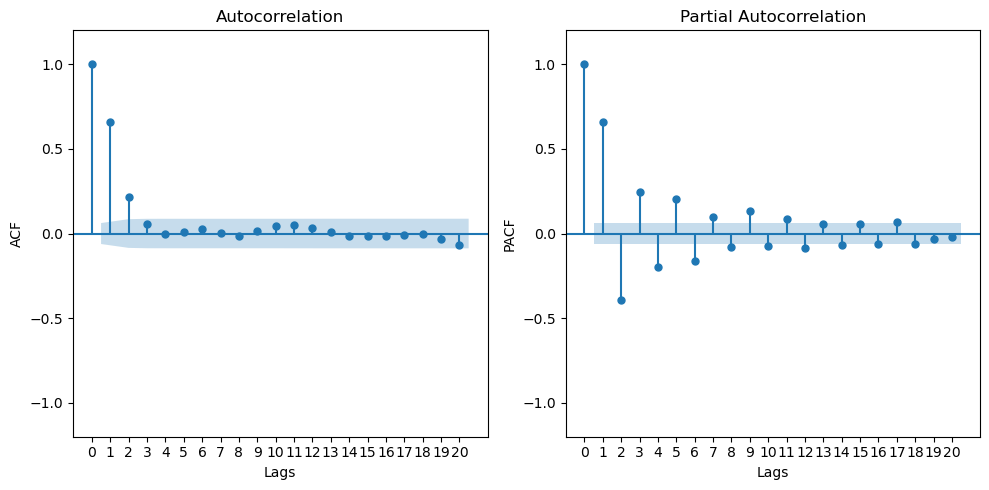

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

plot_acf(arma, lags=20, ax=ax[0])
ax[0].set_xticks(np.arange(0, 21, 1))
ax[0].set_xlabel('Lags')
ax[0].set_ylabel('ACF')
ax[0].set_ylim([-1.2, 1.2])

plot_pacf(arma, lags=20, ax=ax[1])
ax[1].set_xticks(np.arange(0, 21, 1))
ax[1].set_xlabel('Lags')
ax[1].set_ylabel('PACF')
ax[1].set_ylim([-1.2, 1.2])

plt.tight_layout()

plt.show()

# 6.4) Devising a General Modeling Procedure

## 6.4.2) Selecting a model using AIC

In [18]:
order_list = list(product(
    np.arange(0, 4), np.arange(0, 4)
))

In [19]:
order_list

[(np.int64(0), np.int64(0)),
 (np.int64(0), np.int64(1)),
 (np.int64(0), np.int64(2)),
 (np.int64(0), np.int64(3)),
 (np.int64(1), np.int64(0)),
 (np.int64(1), np.int64(1)),
 (np.int64(1), np.int64(2)),
 (np.int64(1), np.int64(3)),
 (np.int64(2), np.int64(0)),
 (np.int64(2), np.int64(1)),
 (np.int64(2), np.int64(2)),
 (np.int64(2), np.int64(3)),
 (np.int64(3), np.int64(0)),
 (np.int64(3), np.int64(1)),
 (np.int64(3), np.int64(2)),
 (np.int64(3), np.int64(3))]

In [20]:
len(order_list)

16

In [21]:
def optimize_AIC(series: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    """
    Compute AIC for each pair of (p, q) on order_list.

    Params:
    -------
    series: Unin[pd.Series, list]
        Univariate time series
    order_list: list
        list with bidimensional tuples with (p, q)

    Returns:
    -------
        A dataframe with three columns: p, q, and AIC.
    """
    p = []
    q = []
    aic =[]

    for order in tqdm(order_list):
        try:
            model = SARIMAX(series, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
        except:
            continue
        p.append(order[0])
        q.append(order[1])
        aic.append(model.aic)

    return pd.DataFrame({
        'p': p, 'q': q, 'aic': aic
    }).sort_values(by='aic', ascending=True).reset_index(drop=True)
        

In [22]:
result = optimize_AIC(arma, order_list)

  0%|          | 0/16 [00:00<?, ?it/s]

/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


!conda install -c conda-forge ipywidgets -y

In [23]:
result

,p,q,aic
0,1,1,2801.407785
1,2,1,2802.906070
2,1,2,2802.967762
3,0,3,2803.666793
4,1,3,2804.524027
5,3,1,2804.588567
6,2,2,2804.822282
7,3,3,2806.026102
8,2,3,2806.175380
9,3,2,2806.894930


## 6.4.4) Performing Residual Analysis

In [24]:
model = SARIMAX(arma, order=(1, 0, 1), simple_differencing=False)
model_fit = model.fit(disp=False)
residuals = model_fit.resid

In [25]:
residuals[:100]

array([ 0.49671415,  0.14772131,  0.44373191,  1.80363131, -0.20982714,
       -0.23742822,  1.57044235,  0.87642338, -0.48627429,  0.56830073,
       -0.46871077, -0.46128581,  0.22020285, -1.9026786 , -1.76321476,
       -0.59592248, -1.04526883,  0.30232606, -0.9300642 , -1.40173568,
        1.42552961, -0.22488404,  0.08762464, -1.44130465, -0.53018441,
        0.0631166 , -1.13128268,  0.35098873, -0.60727907, -0.286631  ,
       -0.62125831,  1.85816372, -0.03723585, -0.99710711,  0.77938272,
       -1.20281184,  0.20542516, -1.98192211, -1.31028986,  0.13236787,
        0.74950777,  0.14971362, -0.08159042, -0.3235393 , -1.45759493,
       -0.74552966, -0.47480883,  1.04037683,  0.33731862, -1.73879105,
        0.31732802, -0.41700581, -0.65197035,  0.57826477,  1.04137391,
        0.92930542, -0.8102944 , -0.30359075,  0.31641472,  0.97824838,
       -0.47780865, -0.16149085, -1.13178094, -1.17766993,  0.76758271,
        1.35863694, -0.06808941,  1.03514561,  0.341755  , -0.59

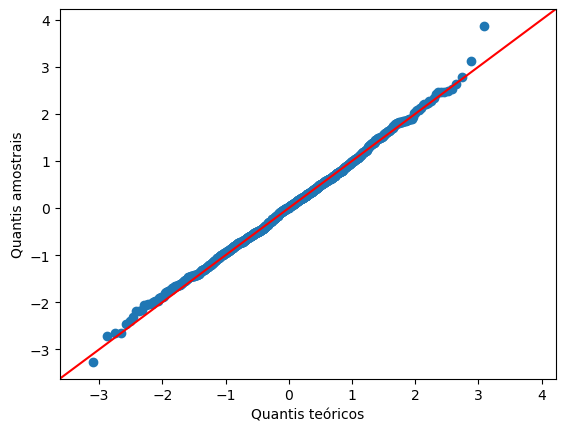

In [26]:
fig, ax = plt.subplots()
qqplot(residuals, line='45', ax=ax)
ax.set_xlabel('Quantis teóricos')
ax.set_ylabel('Quantis amostrais')
plt.show()

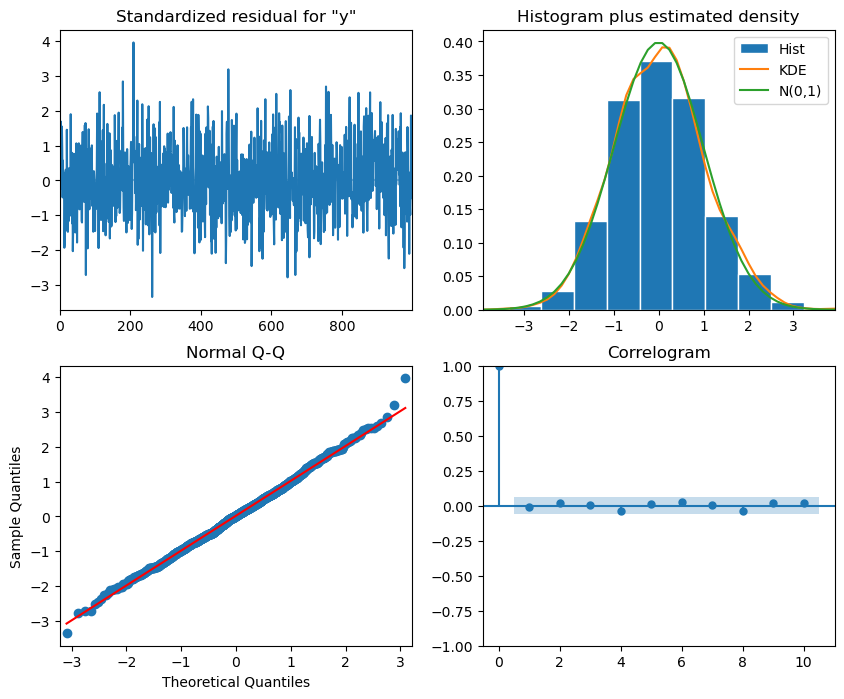

In [27]:
model_fit.plot_diagnostics(figsize=(10, 8));

In [28]:
acorr_ljungbox(residuals, np.arange(1, 11, 1))

,lb_stat,lb_pvalue
1,0.030706,0.860897
2,0.528021,0.767966
3,0.540904,0.909817
4,2.079774,0.721089
5,2.271897,0.810385
6,2.896262,0.821750
7,2.900378,0.894063
8,4.418799,0.817501
9,4.787567,0.852419
10,5.246805,0.874093


# 6.5) Applying the general modeling procedure

In [29]:
df_bandwidth.head()

,hourly_bandwidth
2019-01-01 00:00:00,1000.496714
2019-01-01 01:00:00,1000.969408
2019-01-01 02:00:00,1002.046019
2019-01-01 03:00:00,1004.702118
2019-01-01 04:00:00,1007.447816


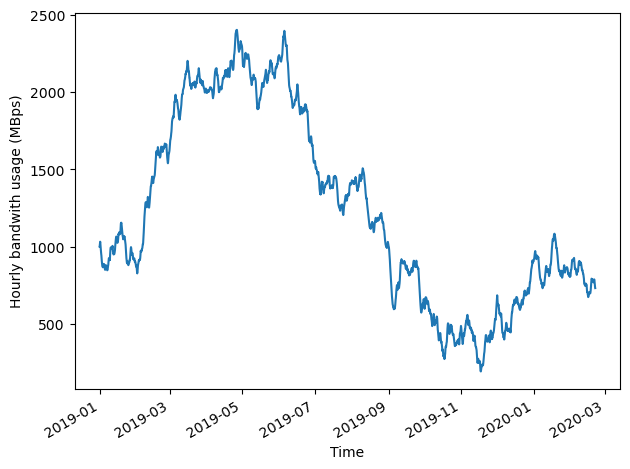

In [30]:
fig, ax = plt.subplots()
ax.plot(df_bandwidth.iloc[:, 0])
ax.set_xlabel('Time')
ax.set_ylabel('Hourly bandwith usage (MBps)')

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

In [31]:
adfuller(df_bandwidth.iloc[:, 0])

(np.float64(-0.8714653199452549),
 np.float64(0.7972240255014611),
 6,
 9993,
 {'1%': np.float64(-3.431004556246501),
  '5%': np.float64(-2.8618292749021865),
  '10%': np.float64(-2.5669239758928017)},
 np.float64(28347.577478302363))

In [32]:
bandwidth_diff = np.diff(df_bandwidth.iloc[:, 0])

In [33]:
adfuller(bandwidth_diff)

(np.float64(-20.69485386378904),
 0.0,
 5,
 9993,
 {'1%': np.float64(-3.431004556246501),
  '5%': np.float64(-2.8618292749021865),
  '10%': np.float64(-2.5669239758928017)},
 np.float64(28344.57207305265))

In [34]:
df_diff = pd.DataFrame({'bandwidth_diff': bandwidth_diff})

In [35]:
df_diff.shape

(9999, 1)

In [36]:
train = df_diff[:-168]
test = df_diff[-168:]

In [37]:
train.shape

(9831, 1)

In [38]:
test.shape

(168, 1)

In [39]:
df_bandwidth.index[-1]

Timestamp('2020-02-21 15:00:00')

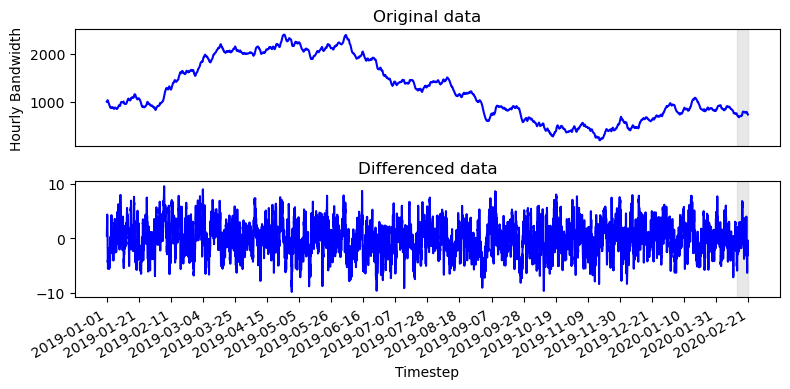

In [40]:
axis_x = np.arange(0, len(df_bandwidth)+1, 500)
fig, ax = plt.subplots(sharex=True, nrows=2, ncols=1, figsize=(8, 4))

ax[0].plot(df_bandwidth.to_numpy(), 'b-')
ax[0].set_title('Original data')
ax[0].set_ylabel('Hourly Bandwidth')
ax[0].axvspan(9831, 10000,
              alpha=0.5, color='lightgray')
ax[0].tick_params(axis='x', length=0)

ax[1].plot(bandwidth_diff, 'b-')
ax[1].set_xticks(axis_x)
ax[1].set_title('Differenced data')
ax[1].set_xticklabels(
    pd.date_range(
        start=df_bandwidth.index[0],
        end=df_bandwidth.index[-1],
        periods=len(axis_x)
    ).strftime("%Y-%m-%d")
)
ax[1].set_xlabel('Timestep')
ax[1].axvspan(9831, 10000,
              alpha=0.5, color='lightgray')

fig.autofmt_xdate()
fig.tight_layout()

plt.show()

In [41]:
 pd.date_range(
        start=df_bandwidth.index[0],
        end=df_bandwidth.index[-1],
        periods=len(axis_x)
    ).strftime("%Y-%m")

Index(['2019-01', '2019-01', '2019-02', '2019-03', '2019-03', '2019-04',
       '2019-05', '2019-05', '2019-06', '2019-07', '2019-07', '2019-08',
       '2019-09', '2019-09', '2019-10', '2019-11', '2019-11', '2019-12',
       '2020-01', '2020-01', '2020-02'],
      dtype='str')

In [42]:
?optimize_AIC

Signature: optimize_AIC(series: pandas.Series | list, order_list: list) -> pandas.DataFrame
Docstring:
Compute AIC for each pair of (p, q) on order_list.

Params:
-------
series: Unin[pd.Series, list]
    Univariate time series
order_list: list
    list with bidimensional tuples with (p, q)

Returns:
-------
    A dataframe with three columns: p, q, and AIC.
File:      /tmp/ipykernel_52586/3629937155.py
Type:      function

In [43]:
k = 4
orders = list(product(np.arange(k), np.arange(k)))
orders[:3]

[(np.int64(0), np.int64(0)),
 (np.int64(0), np.int64(1)),
 (np.int64(0), np.int64(2))]

In [44]:
optimize_AIC(bandwidth_diff, orders)

  0%|          | 0/16 [00:00<?, ?it/s]

/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,p,q,aic
0,3,2,28451.239020
1,2,3,28451.415534
2,2,2,28451.715630
3,3,3,28453.442374
4,1,3,28462.681589
5,1,2,28511.683945
6,3,1,28534.528098
7,3,0,28557.696231
8,2,1,28559.689002
9,2,0,28561.484563


In [45]:
model = SARIMAX(bandwidth_diff, order=(2, 0, 2), simple_differencing=False)
model_fit = model.fit(disp=False)

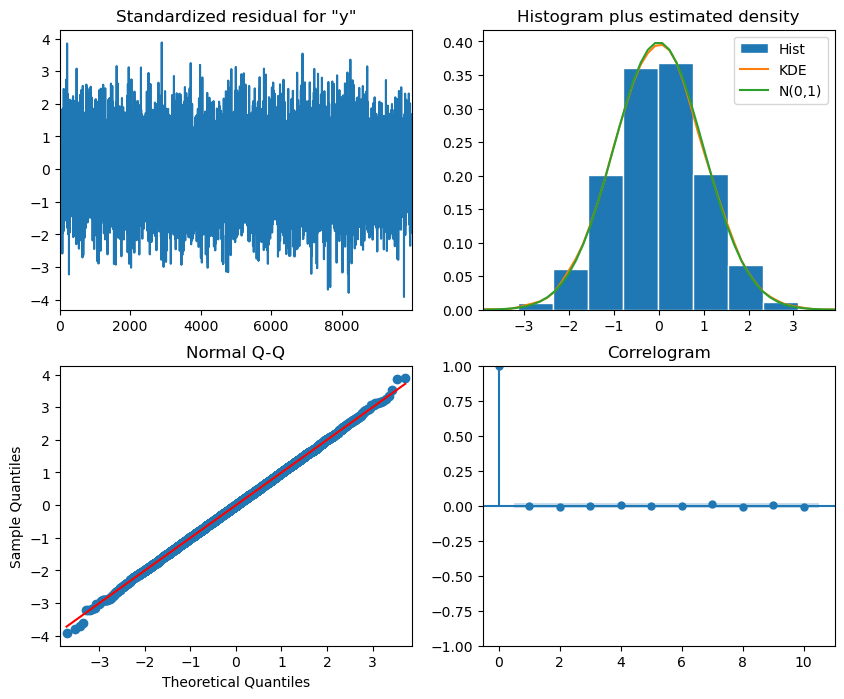

In [46]:
model_fit.plot_diagnostics(figsize=(10, 8));

In [47]:
residuals = model_fit.resid

In [48]:
lb = acorr_ljungbox(residuals, np.arange(1, 11, 1))

In [49]:
lb.columns

Index(['lb_stat', 'lb_pvalue'], dtype='str')

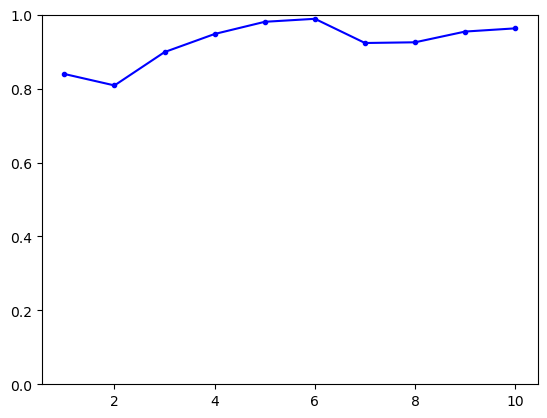

In [50]:
fig, ax = plt.subplots()
ax.plot(lb.lb_pvalue, 'b-', marker='.')
ax.set_ylim([0, 1])
plt.show()

# 6.6) Forecasting bandwidth usage

In [51]:
def rolling_forecast(series: Union[pd.Series, list], train_len: int, horizon: int, window: int, method: str,
                    order: Union[list, tuple] = [2, 0, 2]) -> list:
    """
    Rolling forecast for ARMA(2,2) model.

    Two baseline models are also implemented to comparison: last value and mean.

    Params:
    -------
    series: pd.Series
        Series object with the time series to be predicted.
    train_len: int
        train size
    horizon: int
        how many steps ahead to be predicted
    window: int
        how many steps ahead to be predicted at each iteration
    method: str
        prediction method. It must be one of "mean", "last", "arma".
    order: Union[list, tuple]
        order of ARMA model. Defaults to (2, 0, 2).

    Returns:
    --------
        returns a list of predicted values
    """

    if method not in ['mean', 'last', 'arma']:
        raise ValueError("'method' must be one of ['mean', 'last', 'arma']")

    total_len = train_len + horizon

    # ensure the time_series is a numpy array
    time_series = np.array(series)

    if method == 'mean':
        pred_mean = []

        for i in range(train_len, total_len, window):
            media = np.mean(time_series[:i])
            pred_mean.extend([media for _ in range(window)])
        
        return pred_mean
    elif method == 'last':
        pred_last = []
        
        for i in range(train_len, total_len, window):
            last_value = time_series[i-1]
            pred_last.extend([last_value for _ in range(window)])
        
        return pred_last
    elif method == 'arma':
        pred_arma = []

        for i in range(train_len, total_len, window):
            model = SARIMAX(time_series, order=order)
            model_fit = model.fit(disp=False)
            predictions = model_fit.get_prediction(0, i + window - 1)
            oos_predictions = predictions.predicted_mean[-window:]
            pred_arma.extend(oos_predictions)
        
        return pred_arma
            

In [52]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 9831 to 9998
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bandwidth_diff  168 non-null    float64
dtypes: float64(1)
memory usage: 1.4 KB


In [53]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 9831 entries, 0 to 9830
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bandwidth_diff  9831 non-null   float64
dtypes: float64(1)
memory usage: 76.9 KB


In [54]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

In [55]:
?rolling_forecast

Signature:
rolling_forecast(
    series: pandas.Series | list,
    train_len: int,
    horizon: int,
    window: int,
    method: str,
    order: list | tuple = [2, 0, 2],
) -> list
Docstring:
Rolling forecast for ARMA(2,2) model.

Two baseline models are also implemented to comparison: last value and mean.

Params:
-------
series: pd.Series
    Series object with the time series to be predicted.
train_len: int
    train size
horizon: int
    how many steps ahead to be predicted
window: int
    how many steps ahead to be predicted at each iteration
method: str
    prediction method. It must be one of "mean", "last", "arma".
order: Union[list, tuple]
    order of ARMA model. Defaults to (2, 0, 2).

Returns:
--------
    returns a list of predicted values
File:      /tmp/ipykernel_52586/3650723407.py
Type:      function

In [56]:
df_diff.info()

<class 'pandas.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bandwidth_diff  9999 non-null   float64
dtypes: float64(1)
memory usage: 78.2 KB


In [57]:
pred_df = pd.DataFrame({
    'actual': np.array(test.iloc[:, 0]),
    'mean': rolling_forecast(df_diff.iloc[:, 0], train_len=TRAIN_LEN, window=WINDOW, horizon=HORIZON, method='mean'),
    'last_value': rolling_forecast(df_diff.iloc[:, 0], train_len=TRAIN_LEN, window=WINDOW, horizon=HORIZON,
                                   method='last'),
    'arma': rolling_forecast(df_diff.iloc[:, 0], train_len=TRAIN_LEN, window=WINDOW, horizon=HORIZON, method='arma')
}, index=test.index)

In [58]:
pred_df.head()

,actual,mean,last_value,arma
9831,-5.943995,-0.028214,-5.791207,-5.458171
9832,-5.865194,-0.028214,-5.791207,-5.474077
9833,-3.197066,-0.029410,-5.865194,-5.331905
9834,-1.090197,-0.029410,-5.865194,-2.142016
9835,0.665291,-0.029840,-1.090197,-0.372383


In [59]:
df_diff.head()

,bandwidth_diff
0,0.472694
1,1.076611
2,2.656099
3,2.745698
4,2.246164


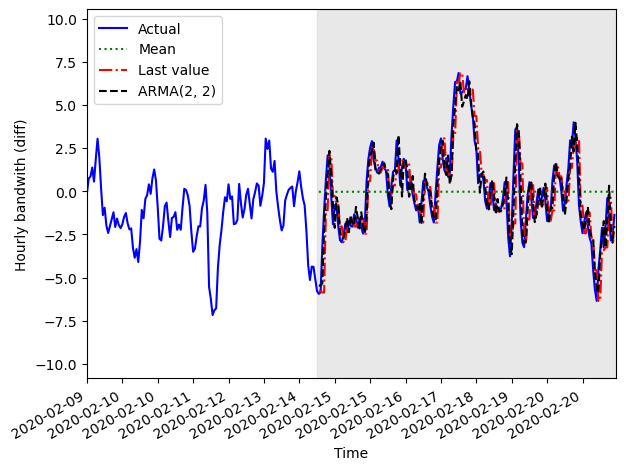

In [60]:
fig, ax = plt.subplots()
ax.plot(df_diff['bandwidth_diff'], 'b-', label='Actual')
ax.plot(pred_df['mean'], 'g:', label='Mean')
ax.plot(pred_df['last_value'], 'r-.', label='Last value')
ax.plot(pred_df['arma'], 'k--', label='ARMA(2, 2)')
ax.legend(loc='upper left')

ax.set_xlabel('Time')
ax.set_ylabel('Hourly bandwith (diff)')

ax.axvspan(9830, 10_000, color='lightgray', alpha=0.5)
ax.set_xlim([9700, 9999])

axis_x = np.arange(9700, 10_000, 20)
ax.set_xticks(axis_x)
ax.set_xticklabels(
    df_bandwidth.index[axis_x].strftime("%Y-%m-%d")
)

fig.tight_layout()
fig.autofmt_xdate()
plt.show()

In [61]:
performance = pd.Series({
    'mean': mean_squared_error(pred_df['actual'], pred_df['mean']),
    'last value': mean_squared_error(pred_df['actual'], pred_df['last_value']),
    'arma(2, 2)': mean_squared_error(pred_df['actual'], pred_df['arma']),
})

In [62]:
performance

mean          6.306527
last value    2.229758
arma(2, 2)    0.899407
dtype: float64

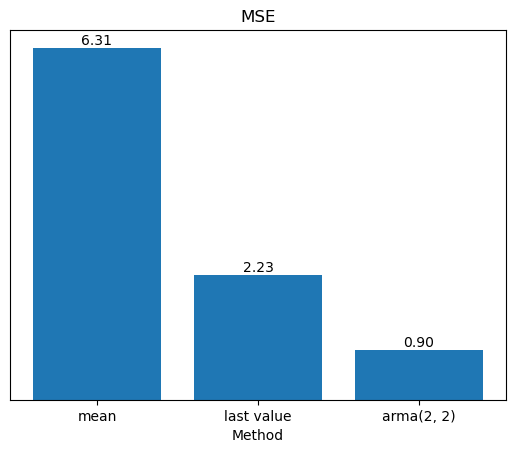

In [63]:
fig, ax = plt.subplots()
bars = ax.bar(performance.index, performance.values)
ax.set_yticks([])
ax.set_xlabel('Method')
ax.set_title('MSE')
ax.bar_label(bars, fmt='%.2f')
plt.show()

In [64]:
pred_df.shape

(168, 4)

In [65]:
pred_df.head()

,actual,mean,last_value,arma
9831,-5.943995,-0.028214,-5.791207,-5.458171
9832,-5.865194,-0.028214,-5.791207,-5.474077
9833,-3.197066,-0.029410,-5.865194,-5.331905
9834,-1.090197,-0.029410,-5.865194,-2.142016
9835,0.665291,-0.029840,-1.090197,-0.372383


In [66]:
train.tail()

,bandwidth_diff
9826,-5.144241
9827,-4.366723
9828,-4.376232
9829,-5.077391
9830,-5.791207


In [67]:
df_bandwidth.tail()

,hourly_bandwidth
2020-02-21 11:00:00,740.546059
2020-02-21 12:00:00,738.906228
2020-02-21 13:00:00,736.057995
2020-02-21 14:00:00,733.559640
2020-02-21 15:00:00,732.190049


In [68]:
df_bandwidth['pred'] = pd.Series()
df_bandwidth.head()

,hourly_bandwidth,pred
2019-01-01 00:00:00,1000.496714,NaN
2019-01-01 01:00:00,1000.969408,NaN
2019-01-01 02:00:00,1002.046019,NaN
2019-01-01 03:00:00,1004.702118,NaN
2019-01-01 04:00:00,1007.447816,NaN


In [69]:
df_bandwidth.iloc[9832:, 1] = np.array(df_bandwidth.iloc[9832, 0] + pred_df.loc[:, 'actual'].cumsum())

In [70]:
df_bandwidth.tail()

,hourly_bandwidth,pred
2020-02-21 11:00:00,740.546059,734.602065
2020-02-21 12:00:00,738.906228,732.962233
2020-02-21 13:00:00,736.057995,730.114001
2020-02-21 14:00:00,733.559640,727.615645
2020-02-21 15:00:00,732.190049,726.246054


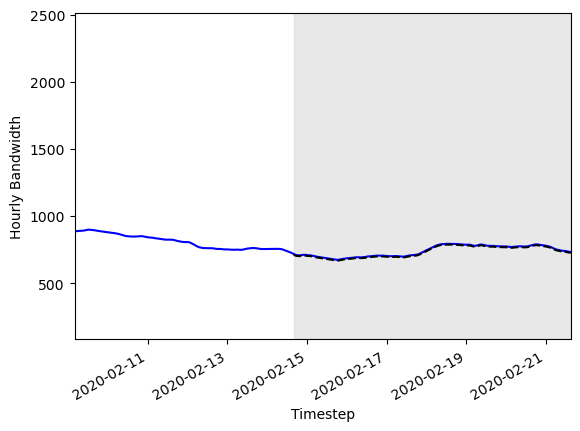

In [71]:
fig, ax = plt.subplots()
ax.plot(df_bandwidth['hourly_bandwidth'], 'b-', label='Observed')
ax.plot(df_bandwidth['pred'], 'k--', label='predicted')
ax.set_xlim([df_bandwidth.index[9700], df_bandwidth.index[9999]])
ax.set_xlabel('Timestep')
ax.set_ylabel('Hourly Bandwidth')
ax.axvspan(
    df_bandwidth.index[9832], df_bandwidth.index[9999],
    color='lightgray', alpha=0.5
)

fig.autofmt_xdate()
plt.show()

In [72]:
mape = mean_absolute_error(
    df_bandwidth.iloc[9832:, 0],df_bandwidth.iloc[9832:, 1]
)

In [73]:
mape

5.9439945401020395

Our forecast is off by 5.94 Mbps above or below the actual bandwith usage.

# QQplot

## Simetria

In [74]:
sample = stats.norm.rvs(loc=0, scale=1, size=1_000)

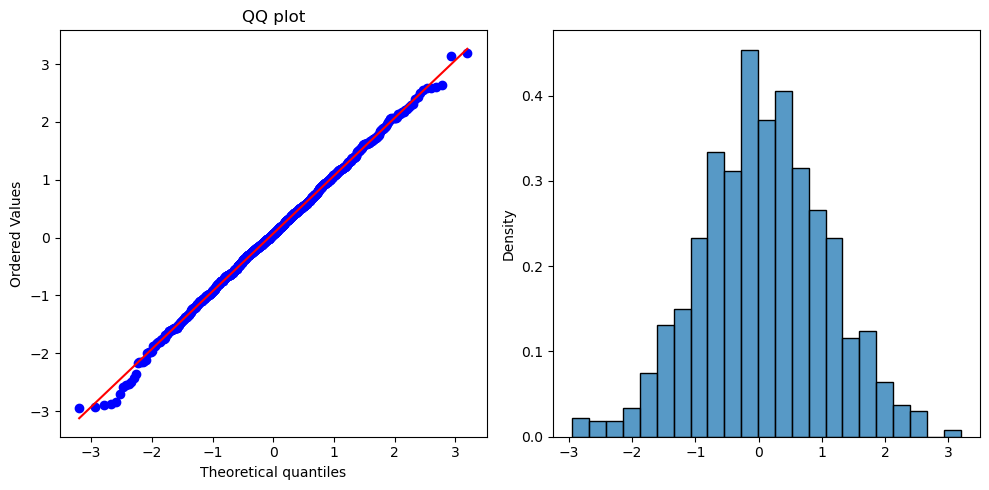

In [75]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
stats.probplot(sample, plot=ax[0])
ax[0].set_title('QQ plot')

sns.histplot(sample, ax=ax[1], stat='density')
fig.tight_layout()
fig.savefig('figuras/qqplot_normality.png')
plt.show()

## Assimetria positiva ou à direita

In [76]:
sample = stats.skewnorm.rvs(a=10, size=1_000)

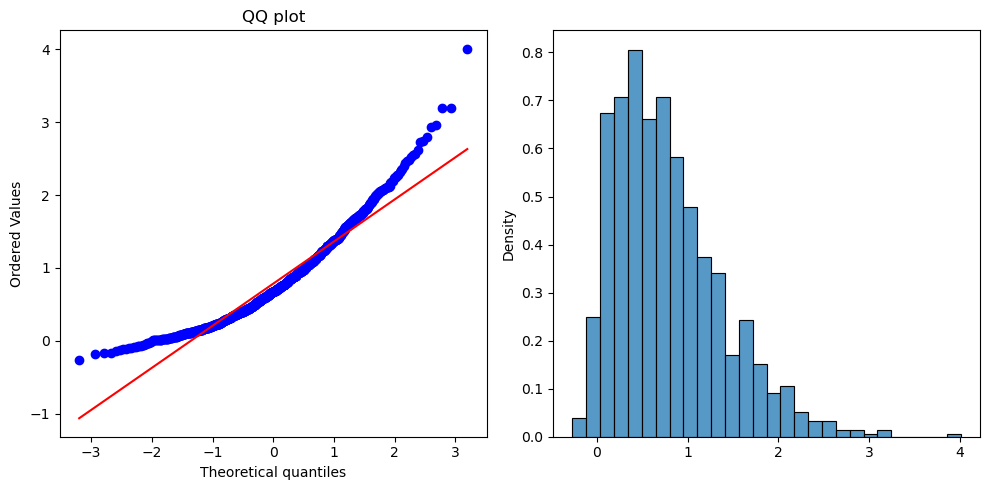

In [77]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
stats.probplot(sample, plot=ax[0])
ax[0].set_title('QQ plot')

sns.histplot(sample, ax=ax[1], stat='density')
fig.tight_layout()
fig.savefig('figuras/qqplot_assimetria_direita.png')
plt.show()

## Assimetria negativa ou à esquerda

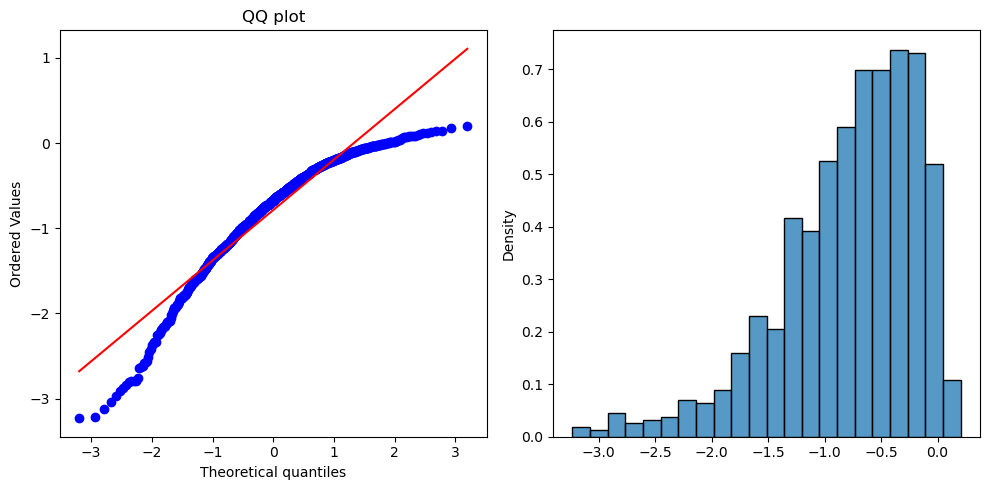

In [78]:
sample = stats.skewnorm.rvs(a=-10, size=1_000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
stats.probplot(sample, plot=ax[0])
ax[0].set_title('QQ plot')

sns.histplot(sample, ax=ax[1], stat='density')
fig.tight_layout()
fig.savefig('figuras/qqplot_assimetria_esquerda.png')
plt.show()

## Calda pesada

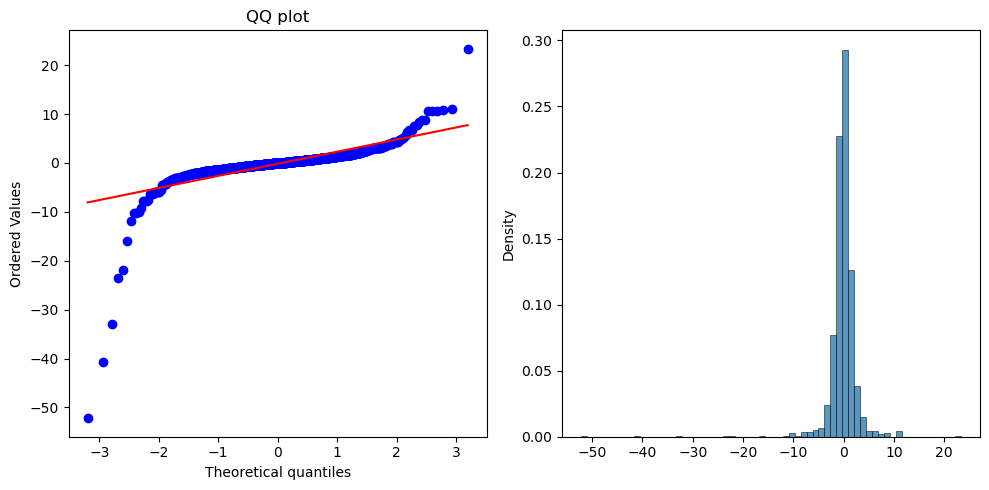

In [79]:
sample = stats.t.rvs(df=2, size=1_000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
stats.probplot(sample, plot=ax[0])
ax[0].set_title('QQ plot')

sns.histplot(sample, ax=ax[1], stat='density')
fig.tight_layout()
fig.savefig('figuras/qqplot_calda_pesada.png')
plt.show()

## Bimodal

In [80]:
sample = []
for _ in trange(1_000):
    u = stats.uniform.rvs(size=1)[0]
    if u < 0.3:
        sample.append(stats.norm.rvs(loc=5, size=1)[0])
    else:
        sample.append(stats.norm.rvs(loc=15, size=1)[0])

  0%|          | 0/1000 [00:00<?, ?it/s]

In [81]:
sample[:5]

[np.float64(3.2774399252475304),
 np.float64(5.122560798827858),
 np.float64(16.42037984802835),
 np.float64(14.177664528647275),
 np.float64(13.02698500001516)]

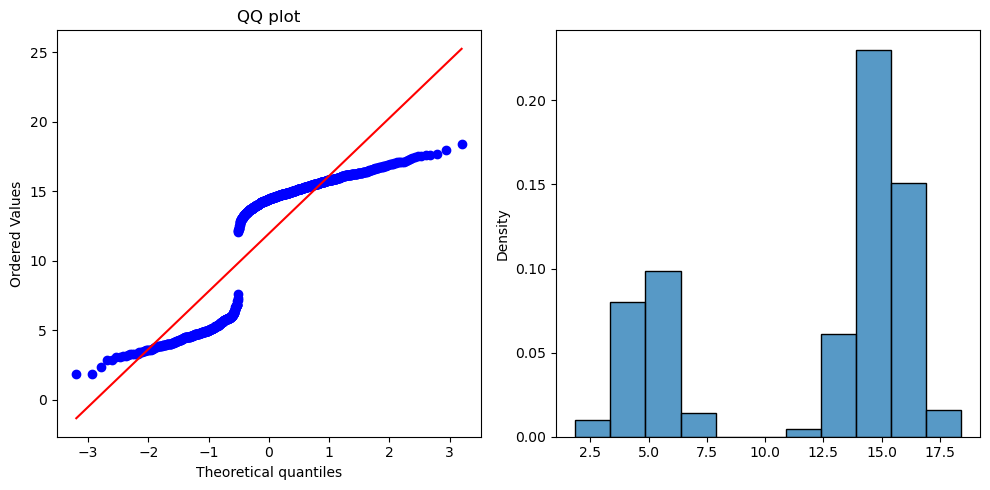

In [82]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
stats.probplot(sample, plot=ax[0])
ax[0].set_title('QQ plot')

sns.histplot(sample, ax=ax[1], stat='density')
fig.tight_layout()
fig.savefig('figuras/qqplot_bimodal.png')
plt.show()